<a href="https://colab.research.google.com/github/ManuJLV/PracticasIA/blob/main/Prism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown as md
import io
from google.colab import files
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [ ]:
uploaded = files.upload()

Saving diabetes_data.csv to diabetes_data.csv


In [ ]:
#cargar uploaded
uploaded

{'diabetes_data.csv': b'Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes\r\n4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0\r\n12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0\r\n13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0\r\n11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0\r\n8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0\r\n1.0,0.0,0.0,1.0,18.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,7.0,0.0,0.0,0.0,0.0,0.0\r\n13.0,1.0,1.0,1.0,26.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0\r\n6.0,1.0,0.0,1.0,31.0,1.0,0.0,0.0,1.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0\r\n3.0,0.0,0.0,1.0,32.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0\r\n6.0,1.0,0.0,1.0,27.0,1.0,0.0,0.0,1.0,1.0,0.0,3.0,0.0,6.0,0.0,0.0,0.0,0.0\r\n12.0,0.0,1.0,1.0,24.0,1.0,1.0,1.0,1.0,1.0,0.

In [ ]:
#cargar el dataframe con los datos del archivo
df = pd.read_csv(io.StringIO(uploaded['diabetes_data.csv'].decode('utf-8')))

In [ ]:
df

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Stroke,HighBP,Diabetes
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0
2,13.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,10.0,0.0,0.0,0.0,0.0
3,11.0,1.0,1.0,1.0,28.0,1.0,0.0,1.0,1.0,1.0,0.0,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,8.0,0.0,0.0,1.0,29.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70687,6.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0
70688,10.0,1.0,1.0,1.0,29.0,1.0,1.0,0.0,1.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0
70689,13.0,0.0,1.0,1.0,25.0,0.0,1.0,0.0,1.0,0.0,0.0,5.0,15.0,0.0,1.0,0.0,1.0,1.0
70690,11.0,0.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,1.0


In [ ]:
df.shape

(70692, 18)

In [ ]:
class PrismAlgorithm:
    def __init__(self, df, target_col):
        self.df = df
        self.target_col = target_col
        self.rules = defaultdict(list)

    def fit(self):
        classes = self.df[self.target_col].unique()

        for cls in classes:
            subset = self.df[self.df[self.target_col] == cls].copy()  # Datos de subconjunto para la clase.
            used_attributes = set()  # Seguimiento de los atributos utilizados para cada clase

            while len(subset) > 0:
                rule = self.generate_rule(subset, cls, used_attributes)
                if rule:
                    self.rules[cls].append(rule)
                    subset = self.apply_rule(subset, rule)  # Eliminar registros que coincidan con la regla
                    used_attributes.add(rule[0])  # Agregar atributo al conjunto usado para evitar la reutilización
                else:
                    break

    def generate_rule(self, subset, cls, used_attributes):
        best_attr, best_value, max_accuracy = None, None, 0

        #Iterar sobre todas las columnas excepto la columna de destino y evitar los atributos utilizados
        for col in self.df.columns:
            if col == self.target_col or col in used_attributes:
                continue

            values = subset[col].unique()

            # Evaluar cada par atributo-valor
            for value in values:
                accuracy = self.evaluate_accuracy(subset, col, value, cls)
                if accuracy > max_accuracy:
                    best_attr, best_value, max_accuracy = col, value, accuracy

        if best_attr is None or max_accuracy == 0:
            return None  # No se encontró ninguna regla válida

        return (best_attr, best_value)

    def evaluate_accuracy(self, subset, attr, value, cls):
        # Calcular la precisión como proporción de registros coincidentes que pertenecen a la clase
        matching_records = subset[subset[attr] == value]
        if len(matching_records) == 0:
            return 0
        accuracy = len(matching_records[matching_records[self.target_col] == cls]) / len(matching_records)
        return accuracy

    def apply_rule(self, subset, rule):
        #Eliminar registros que cumplan la regla del conjunto de datos
        attr, value = rule
        return subset[subset[attr] != value]

    def get_rules(self):
        return self.rules

In [ ]:
# prompt: crea las reglas para la columna 'diagnosis'

from collections import defaultdict

prism = PrismAlgorithm(df, 'diagnosis')
prism.fit()
rules = prism.get_rules()
for cls, class_rules in rules.items():
    print(f"Reglas para la clase {cls}:")
    for rule in class_rules:
        print(f"Si {rule[0]} es {rule[1]}")


Reglas para la clase M:
Si radius_mean es medium
Si texture_mean es medium
Si perimeter_mean es low
Si area_mean es high
Si smoothness_mean es medium
Reglas para la clase B:
Si radius_mean es low
Si texture_mean es low
Si perimeter_mean es medium
Si area_mean es low


In [ ]:
# prompt: Cree conjuntos de entrenamiento y pruebas

from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
X = df.drop('diagnosis', axis=1)  # Características
y = df['diagnosis']  # Variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")


Tamaño del conjunto de entrenamiento: (455, 30)
Tamaño del conjunto de prueba: (114, 30)


In [ ]:
def calculate_coverage(rules, df, target_col):
    covered_instances = 0
    total_instances = len(df)

    # Recorremos cada instancia (fila) del dataset
    for _, row in df.iterrows():
        instance_covered = False

        # Para cada clase en las reglas, comprobamos si se aplica una regla
        for cls, class_rules in rules.items():
            for rule in class_rules:
                attr, value = rule

                # Si la regla coincide con la instancia, comprobamos si pertenece a la clase objetivo
                if row[attr] == value:
                    if row[target_col] == cls:
                        covered_instances += 1
                        instance_covered = True
                        break  # Si la regla cubre esta instancia, no necesitamos seguir comprobando más reglas
            if instance_covered:
                break  # Si la instancia ya fue cubierta, pasamos a la siguiente

    # Calculamos la cobertura como la proporción de instancias correctamente cubiertas
    return covered_instances / total_instances

# Llamada a la función para calcular la cobertura
coverage = calculate_coverage(rules, df, 'diagnosis')
print(f"Cobertura del algoritmo: {coverage:.2%}")


Cobertura del algoritmo: 100.00%


In [ ]:
# prompt: evaluar el algoritmo PRISM en datos de prueba

def evaluate_prism(rules, X_test, y_test):
  correct_predictions = 0
  total_predictions = len(X_test)

  for index, row in X_test.iterrows():
    predicted_class = None
    for cls, class_rules in rules.items():
      for rule in class_rules:
        attr, value = rule
        if row[attr] == value:
          predicted_class = cls
          break  # Si se encuentra una regla que coincide, se detiene la búsqueda
      if predicted_class is not None:
        break  # Si se encuentra una clase predicha, se detiene la búsqueda

    if predicted_class is not None and predicted_class == y_test[index]:
      correct_predictions += 1

  accuracy = correct_predictions / total_predictions
  return accuracy

# Evaluar el algoritmo PRISM en los datos de prueba
accuracy = evaluate_prism(rules, X_test, y_test)
print(f"Precisión del algoritmo PRISM en los datos de prueba: {accuracy:.2%}")


Precisión del algoritmo PRISM en los datos de prueba: 37.72%


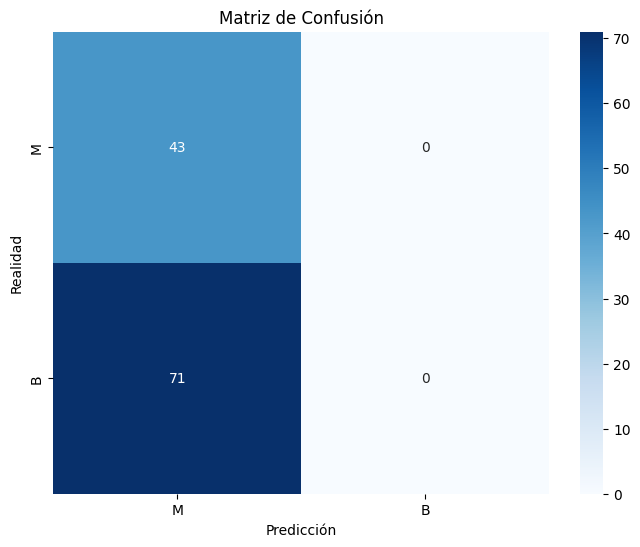

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Función para predecir las instancias de prueba
def predict_instance(rules, instance):
    for cls, class_rules in rules.items():
        for rule in class_rules:
            attr, value = rule
            if instance[attr] == value:
                return cls  # Retorna la clase predicha
    return None  # Si no hay coincidencias

# Generar predicciones para el conjunto de prueba
y_pred = [predict_instance(rules, row) for _, row in X_test.iterrows()]

# Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=df['diagnosis'].unique())

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=df['diagnosis'].unique(), yticklabels=df['diagnosis'].unique())
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()


<ipython-input-59-bfd8b80e74f4>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


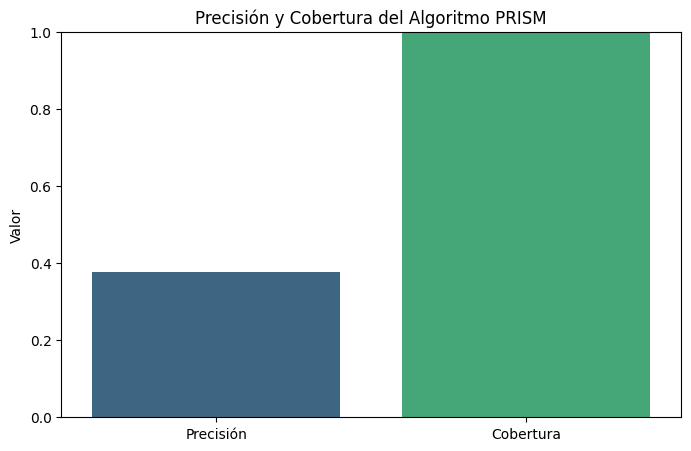

In [ ]:
# Calcular precisión y cobertura
precision = accuracy  # Usamos la precisión que ya calculaste
coverage = calculate_coverage(rules, df, 'diagnosis')

# Graficar precisión y cobertura
metrics = ['Precisión', 'Cobertura']
values = [precision, coverage]

plt.figure(figsize=(8, 5))
sns.barplot(x=metrics, y=values, palette='viridis')
plt.title('Precisión y Cobertura del Algoritmo PRISM')
plt.ylabel('Valor')
plt.ylim(0, 1)  # Escalar entre 0 y 1
plt.show()
